In [31]:
import os
import gc
import glob
import random
import warnings
from collections import Counter
import kagglehub
import numpy as np
import mne
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve, auc, classification_report

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
mne.set_log_level("ERROR")

print("Environment and libraries are ready!")

Environment and libraries are ready!


In [32]:
SEED = 42
BATCH_SIZE = 128         # 🔥 TĂNG LÊN (Từ 32 -> 128) để GPU chạy hết công suất
LEARNING_RATE = 5e-4     # 🔥 TĂNG LÊN (Từ 1e-4 -> 5e-4) để mô hình hội tụ nhanh hơn
MAX_EPOCHS = 15          # 📉 GIẢM XUỐNG (Từ 20 -> 15) vì LR cao sẽ hội tụ sớm hơn
PATIENCE = 3             # 📉 GIẢM XUỐNG (Từ 5 -> 3) để cắt đuôi dừng sớm nhanh hơn nếu loss đứng yên
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAMPLING_RATE = 100      
EPOCH_LEN = 30           
SIGNAL_SIZE = SAMPLING_RATE * EPOCH_LEN 
NUM_CHANNELS = 3         

WINDOW_SIZE = 11          # 📉 GIẢM XUỐNG (Từ 25 -> 15) để giảm độ dài chuỗi ngữ cảnh, mô hình chạy nhẹ hơn
CENTER_IDX = WINDOW_SIZE // 2 

NUM_CLASSES = 5
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
VALID_STAGES = ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R']
MAPPING_STAGES = {'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}

PADDING_MINUTES = 30     
MAX_BREAK_MINUTES = 45   

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)

In [33]:
def load_raw_edf_subjects_list(pattern, padding_minutes=30, max_break_minutes=45):
    all_files = glob.glob(pattern, recursive=True)
    psg_files = sorted([f for f in all_files if f.endswith("PSG.edf")])
    hyp_files = sorted([f for f in all_files if f.endswith("Hypnogram.edf")])

    subjects_data_list = []
    padding_epochs = int(padding_minutes * 60 / 30)
    max_break_epochs = int(max_break_minutes * 60 / 30)
    wake_id = 0 

    for psg, hyp in zip(psg_files, hyp_files):
        try:
            raw = mne.io.read_raw_edf(psg, preload=True, verbose=False)
            
            ch_names = raw.ch_names
            eeg_ch = [c for c in ch_names if "Fpz-Cz" in c][0]
            eog_ch = [c for c in ch_names if "EOG" in c][0]
            emg_ch = [c for c in ch_names if "EMG" in c][0]
            
            raw.pick_channels([eeg_ch, eog_ch, emg_ch])
            raw.filter(0.5, 30.0, fir_design='firwin', verbose=False)
            raw.resample(SAMPLING_RATE, verbose=False) 
            
            annotations = mne.read_annotations(hyp)
            raw.set_annotations(annotations[np.isin(annotations.description, VALID_STAGES)], emit_warning=False)
            events, _ = mne.events_from_annotations(raw, event_id=MAPPING_STAGES, chunk_duration=30.0, verbose=False)

            if len(events) == 0:
                continue

            labels = events[:, -1]
            total_len = len(labels)
            non_wake_indices = np.where(labels != wake_id)[0]
            if len(non_wake_indices) == 0:
                continue 
                
            last_sleep_idx = non_wake_indices[-1]
            first_sleep_idx = non_wake_indices[0]
            current_wake_streak = 0
            has_slept = False

            for i in range(total_len):
                if labels[i] != wake_id:
                    if not has_slept:
                        first_sleep_idx = i
                        has_slept = True
                    current_wake_streak = 0
                else:
                    if has_slept:
                        current_wake_streak += 1
                        if current_wake_streak >= max_break_epochs:
                            has_slept = False
                            current_wake_streak = 0

            start_idx = max(0, first_sleep_idx - padding_epochs)
            end_idx = min(total_len - 1, last_sleep_idx + padding_epochs)
            filtered_events = events[start_idx : end_idx + 1]

            ch_data = raw.get_data() 
            
            del raw
            gc.collect()
            
            X_subject, y_subject = [], []
            for ev in filtered_events:
                start_samp = ev[0]
                end_samp = start_samp + SIGNAL_SIZE
                if end_samp <= ch_data.shape[1]:
                    X_subject.append(ch_data[:, start_samp:end_samp])
                    y_subject.append(ev[-1])

            if X_subject:
                subjects_data_list.append({
                    'file_name': os.path.basename(psg),
                    'signals': np.stack(X_subject, axis=0), 
                    'labels': np.array(y_subject)
                })
                print(f"✅ Loaded: {os.path.basename(psg)} | {len(y_subject)} epochs.")
                
        except Exception as e:
            print(f"⚠️ Skipping file {psg} due to error: {e}")
            continue
            
    return subjects_data_list

In [34]:
def robust_per_subject_scaling(subjects_list):
    scaled_subjects = []
    for sub in subjects_list:
        sub_cp = {'file_name': sub['file_name'], 'labels': sub['labels'].copy()}
        raw_signals = sub['signals'].copy() 
        
        for ch in range(NUM_CHANNELS):
            ch_data = raw_signals[:, ch, :]
            
            q_low = np.percentile(ch_data, 1)
            q_high = np.percentile(ch_data, 99)
            ch_clipped = np.clip(ch_data, q_low, q_high)
            
            mean_val = np.mean(ch_clipped)
            std_val = np.std(ch_clipped) + 1e-6
            raw_signals[:, ch, :] = (ch_clipped - mean_val) / std_val
        
        sub_cp['signals'] = raw_signals
        scaled_subjects.append(sub_cp)
    print(f"-> Robust scaling applied for {len(scaled_subjects)} subjects.")
    return scaled_subjects

In [40]:
# 1. Khối trích xuất đặc trưng CNN nguyên bản từ tín hiệu sóng thô độc lập
class FeatureExtractorCNN(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        # Nhánh CNN với bộ lọc nhỏ (Rút trích đặc trưng tần số cao / chi tiết cục bộ)
        self.small_cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=50, stride=6, padding=25, bias=False), # 🔥 Đã sửa Conv1D -> Conv1d
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=8, stride=8, padding=4), # 🔥 Đã sửa MaxPool1D -> MaxPool1d
            nn.Dropout(0.5),
            nn.Conv1d(64, 128, kernel_size=8, stride=1, padding=4, bias=False), # 🔥 Đã sửa Conv1D -> Conv1d
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=8, stride=1, padding=4, bias=False), # 🔥 Đã sửa Conv1D -> Conv1d
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4, padding=2) # 🔥 Đã sửa MaxPool1D -> MaxPool1d
        )
        # Nhánh CNN với bộ lọc lớn (Rút trích đặc trưng tần số thấp / tổng quát)
        self.large_cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=400, stride=50, padding=200, bias=False), # 🔥 Đã sửa Conv1D -> Conv1d
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=4, stride=4, padding=2), # 🔥 Đã sửa MaxPool1D -> MaxPool1d
            nn.Dropout(0.5),
            nn.Conv1d(64, 128, kernel_size=6, stride=1, padding=3, bias=False), # 🔥 Đã sửa Conv1D -> Conv1d
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=6, stride=1, padding=3, bias=False), # 🔥 Đã sửa Conv1D -> Conv1d
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2, padding=1) # 🔥 Đã sửa MaxPool1D -> MaxPool1d
        )
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x shape: (batch_size, channels, signal_size)
        s_out = self.small_cnn(x)
        l_out = self.large_cnn(x)
        
        # Flatten dữ liệu đặc trưng độc lập từng epoch
        s_out = s_out.view(s_out.size(0), -1)
        l_out = l_out.view(l_out.size(0), -1)
        
        # Kết hợp thông tin từ 2 nhánh tần số
        merged = torch.cat((s_out, l_out), dim=1)
        return self.dropout(merged)


# 2. Khối học chuỗi thời gian ngữ cảnh (LSTM) sau khi nén đặc trưng CNN
class DeepSleepNetLSTM(nn.Module):
    def __init__(self, cnn_out_dim, num_classes=5, hidden_size=512, center_idx=5):
        super().__init__()
        self.center_idx = center_idx
        self.cnn_out_dim = cnn_out_dim
            
        self.lstm = nn.LSTM(
            input_size=self.cnn_out_dim, 
            hidden_size=hidden_size,
            num_layers=2, 
            batch_first=True, \
            bidirectional=True, \
            dropout=0.5
        )
        
        self.residual_projector = nn.Linear(self.cnn_out_dim, hidden_size * 2)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), 
            nn.Linear(hidden_size * 2, num_classes)
        )

    def forward(self, features_sequence):
        lstm_out, _ = self.lstm(features_sequence) 
        residual_shortcut = self.residual_projector(features_sequence)
        temporal_features = lstm_out + residual_shortcut 
        
        # Lấy nhãn dự đoán cho epoch nằm chính giữa cửa sổ trượt ngữ cảnh
        center_epoch_features = temporal_features[:, self.center_idx, :] 
        return self.classifier(center_epoch_features)


# 3. Lớp Dataset nạp đặc trưng số siêu tốc từ RAM thay vì đọc tín hiệu thô
class DeepSleepNetDataset(Dataset):
    def __init__(self, subjects_list, window_size=11, center_idx=5):
        self.window_size = window_size
        self.center_idx = center_idx
        self.samples = []
        
        self.subjects_features = [sub['cnn_features'] for sub in subjects_list]
        
        for sub_idx, sub in enumerate(subjects_list):
            labels = sub['labels']
            if len(labels) < window_size:
                continue
            
            for i in range(len(labels) - window_size + 1):
                center_label = labels[i + center_idx]
                self.samples.append((sub_idx, i, center_label))
        self.labels = np.array([s[2] for s in self.samples], dtype=np.int64)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sub_idx, start_idx, center_label = self.samples[idx]
        window_data = self.subjects_features[sub_idx][start_idx : start_idx + self.window_size]
        return torch.tensor(window_data, dtype=torch.float32), torch.tensor(center_label, dtype=torch.int64)

In [36]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for x_b, y_b in dataloader:
        x_b = x_b.to(device, non_blocking=True)
        y_b = y_b.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        logits = model(x_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x_b.size(0)
    return total_loss / len(dataloader.dataset)

def validate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []
    with torch.no_grad():
        for x_b, y_b in dataloader:
            x_b = x_b.to(device, non_blocking=True)
            y_b = y_b.to(device, non_blocking=True)
            
            logits = model(x_b)
            loss = criterion(logits, y_b)
            total_loss += loss.item() * x_b.size(0)
            
            preds.extend(torch.argmax(logits, dim=-1).detach().cpu().numpy())
            targets.extend(y_b.detach().cpu().numpy())
            
    avg_loss = total_loss / len(dataloader.dataset)
    macro_f1 = f1_score(targets, preds, average='macro', zero_division=0)
    acc = accuracy_score(targets, preds)
    return avg_loss, macro_f1, acc

In [ ]:
print("⏳ Connecting to Kaggle to download/check EDF data...")

try:
    extract_target = kagglehub.dataset_download(
        "ledaihoangnguyentmu/small-sleep-edf-database"
        # "ledaihoangnguyentmu/sleep-edf-database-expanded-1-0-0-zip"
    )
    print(f"✅ Dataset located locally: {extract_target}")

    path_cassette_pattern = os.path.join(extract_target, "**", "sleep-cassette", "**", "*.edf")
    path_telemetry_pattern = os.path.join(extract_target, "**", "sleep-telemetry", "**", "*.edf")

    print("\n⏳ Loading raw multi-channel signals using pattern paths...")
    raw_cassette_data = load_raw_edf_subjects_list(path_cassette_pattern)
    raw_telemetry_data = load_raw_edf_subjects_list(path_telemetry_pattern)

    print("\n⏳ Applying robust per-subject scaling...")
    raw_cassette_data = robust_per_subject_scaling(raw_cassette_data)
    raw_telemetry_data = robust_per_subject_scaling(raw_telemetry_data)

    gc.collect()
    print("✅ Successfully loaded and normalized EDF data locally!")

except Exception as e:
    print(f"\n❌ [SYSTEM ERROR]: {e}")

⏳ Connecting to Kaggle to download/check EDF data...
✅ Dataset located locally: /Users/nguyenle/.cache/kagglehub/datasets/ledaihoangnguyentmu/small-sleep-edf-database/versions/1

⏳ Loading raw multi-channel signals using pattern paths...
✅ Loaded: SC4001E0-PSG.edf | 841 epochs.
✅ Loaded: SC4002E0-PSG.edf | 1127 epochs.
✅ Loaded: ST7011J0-PSG.edf | 1092 epochs.
✅ Loaded: ST7012J0-PSG.edf | 1040 epochs.

⏳ Applying robust per-subject scaling...
-> Robust scaling applied for 2 subjects.
-> Robust scaling applied for 2 subjects.
✅ Successfully loaded and normalized EDF data locally!


In [38]:
total_files = len(raw_cassette_data)
file_majority_labels = [int(Counter(sub['labels']).most_common(1)[0][0]) for sub in raw_cassette_data]

label_counts = Counter(file_majority_labels)
min_class_count = min(label_counts.values())

if total_files < 10:
    suggested_splits = 2
else:
    suggested_splits = 5

n_splits = min(suggested_splits, min_class_count)
n_splits = max(2, n_splits)

print(f"📁 Total files: {total_files}")
print(f"⚠️ Rarest label appears in: {min_class_count} files")
print(f"🚀 Configured n_splits: {n_splits} fold")

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

all_folds_data = []      
final_gap_targets = []   
final_gap_preds = []     
final_gap_probs = []
fold_results = []

📁 Total files: 2
⚠️ Rarest label appears in: 2 files
🚀 Configured n_splits: 2 fold


In [41]:
# Khởi tạo mô hình CNN extractor để xử lý nén dữ liệu 1 lần duy nhất
cnn_extractor = FeatureExtractorCNN(in_channels=NUM_CHANNELS).to(DEVICE)
cnn_extractor.eval()

print("⏳ Đang tiền xử lý: Ép toàn bộ sóng thô qua CNN 1 lần duy nhất...")

# Tự động tính kích thước đầu ra thực tế của tầng CNN để truyền vào LSTM
with torch.no_grad():
    dummy_input = torch.zeros(1, NUM_CHANNELS, SIGNAL_SIZE).to(DEVICE)
    CNN_OUT_DIM = cnn_extractor(dummy_input).shape[1]

# Tiến hành trích xuất trước và lưu thẳng vào danh sách dữ liệu trong RAM
with torch.no_grad():
    print(" -> Trích xuất đặc trưng tập Cassette...")
    for sub in raw_cassette_data:
        signals_tensor = torch.tensor(sub['signals'], dtype=torch.float32).to(DEVICE)
        # Chạy CNN theo từng batch nhỏ nếu số lượng epoch quá lớn tránh tràn bộ nhớ GPU
        features = cnn_extractor(signals_tensor)
        sub['cnn_features'] = features.cpu().numpy()

    print(" -> Trích xuất đặc trưng tập Telemetry...")
    for sub in raw_telemetry_data:
        signals_tensor = torch.tensor(sub['signals'], dtype=torch.float32).to(DEVICE)
        features = cnn_extractor(signals_tensor)
        sub['cnn_features'] = features.cpu().numpy()

print(f"✅ Đã trích xuất xong đặc trưng CNN! Chiều đặc trưng đầu ra: {CNN_OUT_DIM}")
# Giải phóng extractor khỏi bộ nhớ vì không cần train lại tầng CNN nữa
del cnn_extractor
torch.cuda.empty_cache()
gc.collect()

⏳ Đang tiền xử lý: Ép toàn bộ sóng thô qua CNN 1 lần duy nhất...
 -> Trích xuất đặc trưng tập Cassette...
 -> Trích xuất đặc trưng tập Telemetry...
✅ Đã trích xuất xong đặc trưng CNN! Chiều đặc trưng đầu ra: 3456


40

In [42]:
# --- BƯỚC Huấn luyện K-Fold Cross Validation ---
for fold, (train_idx, val_idx) in enumerate(skf.split(raw_cassette_data, file_majority_labels), 1):
    print(f"\n=================== START FOLD {fold}/{n_splits} ===================")
    
    train_subs = [raw_cassette_data[i] for i in train_idx]
    val_subs = [raw_cassette_data[i] for i in val_idx]
    
    train_set = DeepSleepNetDataset(train_subs, window_size=WINDOW_SIZE, center_idx=CENTER_IDX)
    val_set = DeepSleepNetDataset(val_subs, window_size=WINDOW_SIZE, center_idx=CENTER_IDX)
    test_set = DeepSleepNetDataset(raw_telemetry_data, window_size=WINDOW_SIZE, center_idx=CENTER_IDX)
    
    # 🔥 ĐÃ SỬA: num_workers=0 để tránh triệt để lỗi đa tiến trình AttributeError đóng băng luồng trên macOS/Notebook
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = DeepSleepNetLSTM(cnn_out_dim=CNN_OUT_DIM, num_classes=NUM_CLASSES, center_idx=CENTER_IDX).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    # Huấn luyện mô hình chuỗi thời gian dựa trên các siêu tham số động đã cấu hình
    for epoch in range(1, MAX_EPOCHS + 1): 
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_f1, val_acc = validate_model(model, val_loader, criterion, DEVICE)
        
        print(f" Ep {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(" ⏹️ Kích hoạt cơ chế dừng sớm (Early Stopping).")
                break
                
    # Nạp lại trọng số tốt nhất thu được của fold hiện tại
    model.load_state_dict(best_model_state)
    model.to(DEVICE)
    model.eval()
    
    test_probs, test_preds, test_targets = [], [], []
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b = x_b.to(DEVICE, non_blocking=True)
            logits = model(x_b)
            probs = F.softmax(logits, dim=-1) 
            
            test_probs.extend(probs.detach().cpu().numpy())
            test_preds.extend(torch.argmax(logits, dim=-1).detach().cpu().numpy())
            test_targets.extend(y_b.numpy())
            
    test_probs = np.array(test_probs)
    test_targets = np.array(test_targets)
    test_preds = np.array(test_preds)
    
    all_folds_data.append((test_targets, test_probs))
    final_gap_targets.extend(test_targets)
    final_gap_preds.extend(test_preds)
    final_gap_probs.extend(test_probs)  # Thu thập mảng xác suất đầu ra cho hàm in báo cáo PR-AUC
    
    # Tính PR-AUC cục bộ cho fold
    classes_list = list(range(NUM_CLASSES))
    y_true_bin = label_binarize(test_targets, classes=classes_list)
    if NUM_CLASSES == 2 and y_true_bin.shape[1] == 1:
        y_true_bin = np.hstack((1 - y_true_bin, y_true_bin))

    fold_pr_aucs = []
    for c in range(NUM_CLASSES):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, c], test_probs[:, c])
        pr_auc = auc(recall, precision)
        fold_pr_aucs.append(pr_auc)
    macro_pr_auc = np.mean(fold_pr_aucs)
    
    test_acc = accuracy_score(test_targets, test_preds)
    test_prec = precision_score(test_targets, test_preds, average='macro', zero_division=0)
    test_rec = recall_score(test_targets, test_preds, average='macro', zero_division=0)
    test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)
    
    print(f"✨ KẾT QUẢ FOLD {fold} TRÊN TẬP ĐỘC LẬP TELEMETRY:")
    print(f"   -> Accuracy = {test_acc:.4f} | Macro Precision = {test_prec:.4f} | Macro Recall = {test_rec:.4f}")
    print(f"   -> Macro F1 = {test_f1:.4f}  | 🚀 Macro PR-AUC = {macro_pr_auc:.4f}")
    
    fold_results.append({
        'acc': test_acc, 
        'precision': test_prec, 
        'recall': test_rec, 
        'f1': test_f1,
        'pr_auc': macro_pr_auc  
    })
    
    # Giải phóng triệt để cấu trúc tránh hiện tượng rò rỉ bộ nhớ đồ thị tính toán
    del model, optimizer, train_set, val_set, test_set
    torch.cuda.empty_cache()
    gc.collect()

print("\n⚙️ Đang chuẩn bị xuất báo cáo tổng hợp và đồ thị PR-AUC cuối cùng...")


=================== START FOLD 1/2 ===================
 Ep 01 | Train Loss: 2.3046 | Val Loss: 1.5861 | Val F1: 0.1001
 Ep 02 | Train Loss: 1.6511 | Val Loss: 1.7711 | Val F1: 0.0536
 Ep 03 | Train Loss: 1.6064 | Val Loss: 1.3551 | Val F1: 0.3052
 Ep 04 | Train Loss: 1.3190 | Val Loss: 1.2890 | Val F1: 0.3385
 Ep 05 | Train Loss: 1.2579 | Val Loss: 1.2434 | Val F1: 0.3660
 Ep 06 | Train Loss: 1.1632 | Val Loss: 1.1174 | Val F1: 0.4133
 Ep 07 | Train Loss: 1.0954 | Val Loss: 0.9984 | Val F1: 0.4316
 Ep 08 | Train Loss: 0.9555 | Val Loss: 0.9622 | Val F1: 0.4759
 Ep 09 | Train Loss: 0.9292 | Val Loss: 0.8794 | Val F1: 0.4896
 Ep 10 | Train Loss: 0.8234 | Val Loss: 0.8472 | Val F1: 0.4809
 Ep 11 | Train Loss: 0.7238 | Val Loss: 0.9840 | Val F1: 0.4452
 Ep 12 | Train Loss: 0.7071 | Val Loss: 1.2261 | Val F1: 0.4138
 Ep 13 | Train Loss: 0.8743 | Val Loss: 0.8447 | Val F1: 0.5785
 Ep 14 | Train Loss: 0.7797 | Val Loss: 0.9409 | Val F1: 0.4166
 Ep 15 | Train Loss: 0.6846 | Val Loss: 0.7599 |

In [43]:
def print_detailed_class_metrics(all_targets, all_preds, all_probs, class_names):
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    num_classes = len(class_names)
    
    print("\n📊 DETAILED PERFORMANCE TABLE BY SLEEP STAGE (TELEMETRY TOTAL):")
    print("-" * 95)
    
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    
    classes_list = list(range(num_classes))
    y_true_bin = label_binarize(y_true, classes=classes_list)
    
    if num_classes == 2 and y_true_bin.shape[1] == 1:
        y_true_bin = np.hstack((1 - y_true_bin, y_true_bin))
    
    per_class_pr_auc = {}
    for i, label in enumerate(class_names):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        per_class_pr_auc[label] = auc(recall, precision)
    
    print(f"{'Stage':<12} | {'Precision':<12} | {'Recall':<15} | {'F1-Score':<12} | {'🚀 PR-AUC':<12} | {'Support'}")
    print("-" * 95)
    
    for label in class_names:
        metrics = report_dict[label]
        pr_auc_val = per_class_pr_auc[label]
        print(f"{label:<12} | {metrics['precision']:<12.4f} | {metrics['recall']:<15.4f} | {metrics['f1-score']:<12.4f} | {pr_auc_val:<12.4f} | {int(metrics['support']):<12}")
    
    print("-" * 95)
    
    macro_metrics = report_dict['macro avg']
    macro_pr_auc = np.mean(list(per_class_pr_auc.values())) 
    
    print(f"{'Macro Average':<12} | {macro_metrics['precision']:<12.4f} | {macro_metrics['recall']:<15.4f} | {macro_metrics['f1-score']:<12.4f} | {macro_pr_auc:<12.4f} | {int(macro_metrics['support']):<12}")
    print("-" * 95)

In [44]:
def plot_multiclass_pr_curve_across_folds(all_folds_data, class_names):
    n_classes = len(class_names)
    
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(n_classes)]
    
    mean_recall = np.linspace(0, 1, 100)
    
    plt.figure(figsize=(9, 7))
    all_classes_mean_aucs = []
    
    for class_idx in range(n_classes):
        fold_precisions = []
        fold_aucs = []
        
        for y_true, y_probs in all_folds_data:
            y_one_hot = label_binarize(y_true, classes=list(range(n_classes)))
            
            if n_classes == 2 and y_one_hot.shape[1] == 1:
                y_one_hot = np.hstack((1 - y_one_hot, y_one_hot))
            
            precision, recall, _ = precision_recall_curve(y_one_hot[:, class_idx], y_probs[:, class_idx])
            
            interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
            
            fold_precisions.append(interp_precision)
            fold_aucs.append(auc(recall, precision))
        mean_precision = np.mean(fold_precisions, axis=0)
        
        mean_precision[0] = 1.0  
        
        std_precision = np.std(fold_precisions, axis=0)
        
        mean_auc = np.mean(fold_aucs)
        std_auc = np.std(fold_aucs)
        all_classes_mean_aucs.append(mean_auc)
        
        plt.plot(mean_recall, mean_precision, color=colors[class_idx], lw=2.5,
                 label=f'{class_names[class_idx]} (PR-AUC = {mean_auc:.2f} ± {std_auc:.2f})')
        
        precision_upper = np.minimum(mean_precision + std_precision, 1)
        precision_lower = np.maximum(mean_precision - std_precision, 0)
        plt.fill_between(mean_recall, precision_lower, precision_upper, 
                         color=colors[class_idx], alpha=0.12)
    macro_pr_auc = np.mean(all_classes_mean_aucs)
    
    plt.axhline(y=1/n_classes, color='gray', linestyle='--', alpha=0.7, 
                label=f'Random baseline (1/{n_classes} = {1/n_classes:.2f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=11)
    plt.ylabel('Precision', fontsize=11)
    
    total_folds = len(all_folds_data)
    plt.title(f'Average Precision-Recall Curve across {total_folds}-Folds\n(Telemetry Macro PR-AUC = {macro_pr_auc:.2f})', 
              fontsize=13, fontweight='bold', pad=12)
    plt.legend(loc="lower left", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


⚙️ Generating summary report and PR-AUC plots...

📊 AVERAGE PERFORMANCE ACROSS 2-FOLDS (TELEMETRY):
-------------------------------------------------------
 - Mean Accuracy:        0.5414
 - Mean Macro Precision: 0.4769
 - Mean Macro Recall:    0.4890
 - Mean Macro F1-Score:  0.4195
 - Mean Macro PR-AUC:   0.5915
-------------------------------------------------------

📊 DETAILED PERFORMANCE TABLE BY SLEEP STAGE (TELEMETRY TOTAL):
-----------------------------------------------------------------------------------------------
Stage        | Precision    | Recall          | F1-Score     | 🚀 PR-AUC     | Support
-----------------------------------------------------------------------------------------------
Wake         | 0.3062       | 0.7021          | 0.4265       | 0.4744       | 574         
N1           | 0.0000       | 0.0000          | 0.0000       | 0.1439       | 326         
N2           | 0.8627       | 0.5552          | 0.6756       | 0.8398       | 2230        
N3           

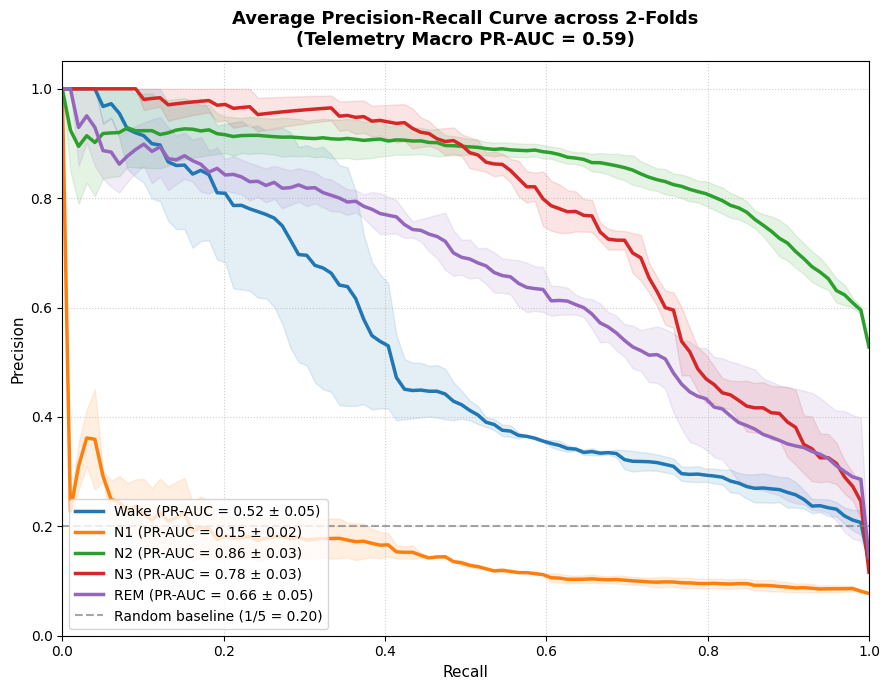

In [45]:
print("\n⚙️ Generating summary report and PR-AUC plots...")

mean_acc = np.mean([f['acc'] for f in fold_results])
mean_prec = np.mean([f['precision'] for f in fold_results])
mean_rec = np.mean([f['recall'] for f in fold_results])
mean_f1 = np.mean([f['f1'] for f in fold_results])
mean_pr_auc = np.mean([f['pr_auc'] for f in fold_results])

total_folds_run = len(fold_results)
print(f"\n📊 AVERAGE PERFORMANCE ACROSS {total_folds_run}-FOLDS (TELEMETRY):")
print("-" * 55)
print(f" - Mean Accuracy:        {mean_acc:.4f}")
print(f" - Mean Macro Precision: {mean_prec:.4f}")
print(f" - Mean Macro Recall:    {mean_rec:.4f}")
print(f" - Mean Macro F1-Score:  {mean_f1:.4f}")
print(f" - Mean Macro PR-AUC:   {mean_pr_auc:.4f}") 
print("-" * 55)

class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
print_detailed_class_metrics(final_gap_targets, final_gap_preds, final_gap_probs, class_names)

plot_multiclass_pr_curve_across_folds(all_folds_data, class_names)